
                                                               Logistic Regression

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, roc_curve
from sklearn.preprocessing import StandardScaler

In [2]:
df=pd.read_csv("diabetes.csv")

In [3]:
print("First 5 rows:")
print(df.head())

First 5 rows:
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  


In [4]:
print("\nDataset Info:")
print(df.info())

print("\nSummary Statistics:")
print(df.describe())


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB
None

Summary Statistics:
       Pregnancies     Glucose  BloodPressure  SkinThickness     Insulin  \
count   768.000000  768.000000     768.000000     768.000000  768.000000   
mean      3.845052  120.894531      69.105469  

In [5]:
print("\nMissing Values:\n",df.isnull().sum())


Missing Values:
 Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


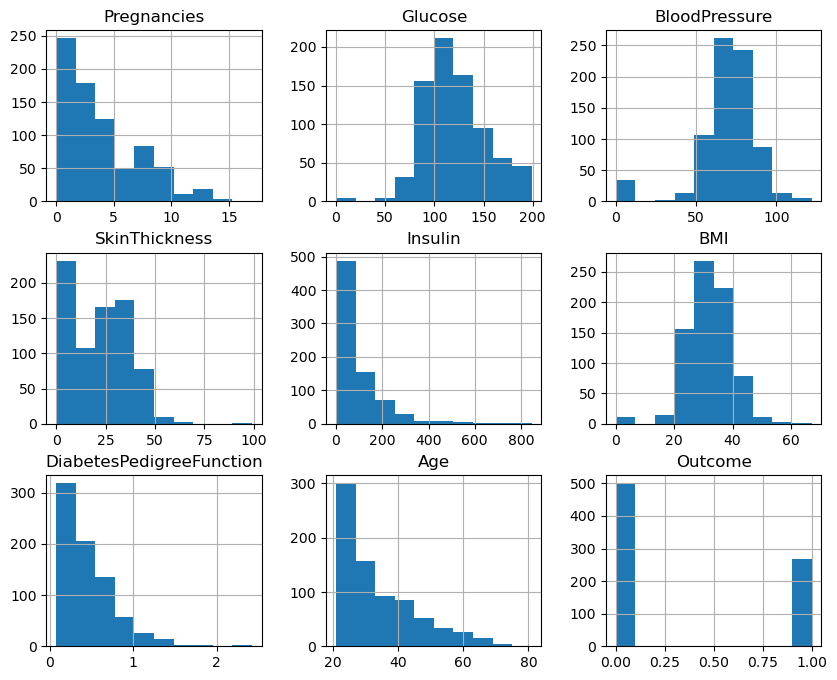

In [7]:
df.hist(figsize=(10,8))
plt.show()

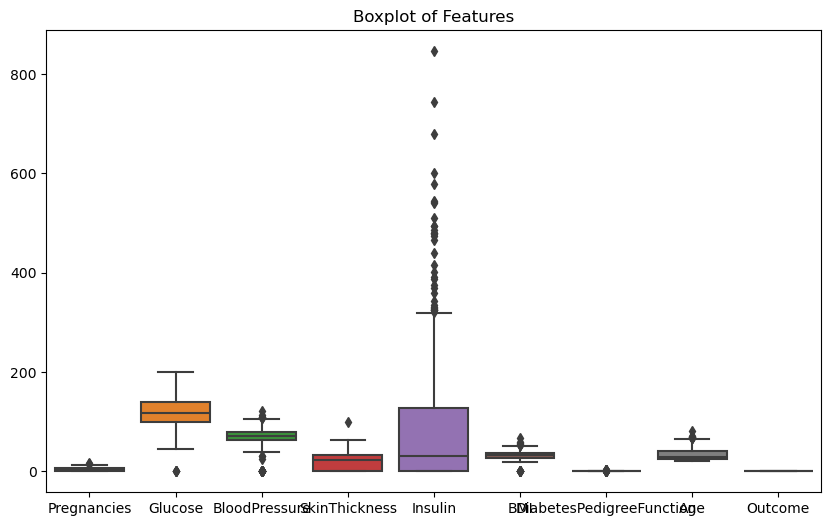

In [8]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df)
plt.title("Boxplot of Features")
plt.show()

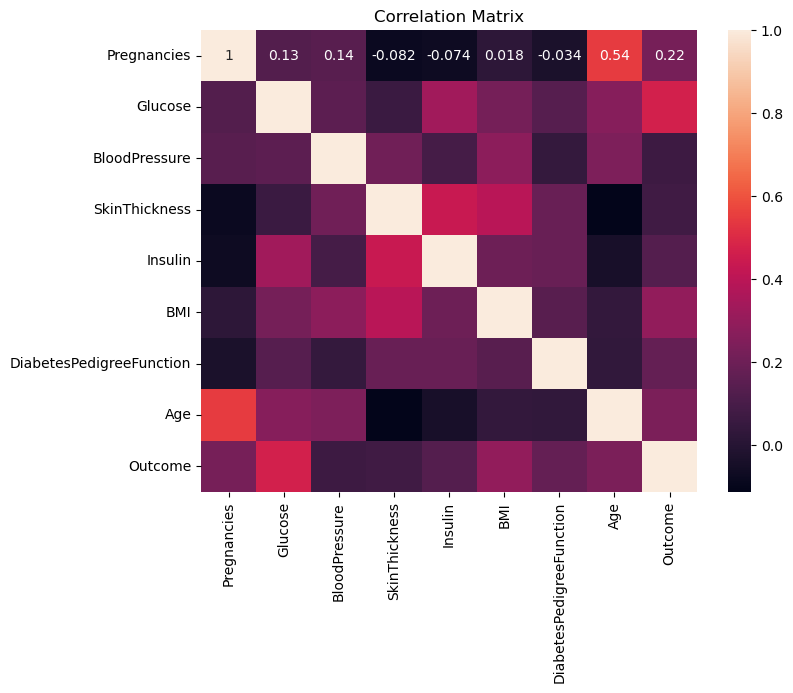

In [9]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True)
plt.title("Correlation Matrix")
plt.show()

In [10]:
# Replace zero values with median (for certain columns)
cols=["Glucose","BloodPressure","SkinThickness","Insulin","BMI"]
for col in cols:
    df[col]=df[col].replace(0,df[col].median())

In [11]:
# Define features and target
X=df.drop("Outcome",axis=1)
y=df["Outcome"]

In [12]:
X_train,X_test,y_train,y_test=train_test_split(
    X,y,test_size=0.2, random_state=42)

In [13]:
#Feature scaling
scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

In [14]:
#Model building
model=LogisticRegression()
model.fit(X_train, y_train)

LogisticRegression()

In [ ]:
import pickle
pickle.dump(model, open("model.pkl", "wb"))

In [15]:
y_pred=model.predict(X_test)
y_prob=model.predict_proba(X_test)[:,1]

In [16]:
print("\nAccuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nROC-AUC Score:", roc_auc_score(y_test, y_prob))


Accuracy: 0.7662337662337663

Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.83      0.82        99
           1       0.68      0.65      0.67        55

    accuracy                           0.77       154
   macro avg       0.75      0.74      0.74       154
weighted avg       0.76      0.77      0.77       154


ROC-AUC Score: 0.8196510560146923


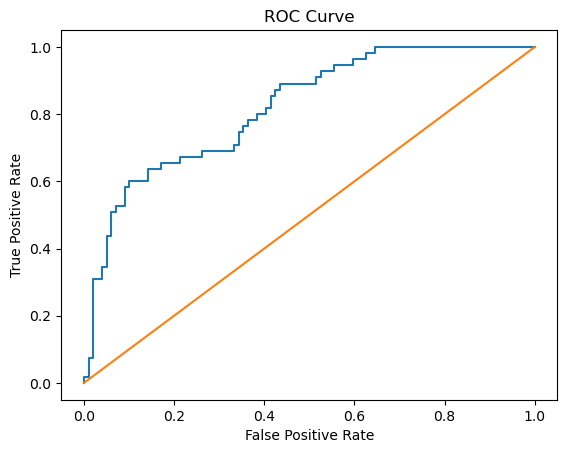

In [17]:
#ROC curve
fpr,tpr,thresholds=roc_curve(y_test,y_prob)

plt.figure()
plt.plot(fpr, tpr)
plt.plot([0,1], [0,1]) 
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

In [ ]:
coefficients=pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_[0]})
print("\nFeature Importance:")
print(coefficients.sort_values(by="Coefficient",ascending=False))

Interpretation
Positive value - increases probability of diabetes
Negative value - decreases probability